This notebook rectifies the Hamiltonian from therm_polaritons.ipynb and continues the study

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.random import default_rng
from scipy.optimize import minimize_scalar
import matplotlib.cm as cm
import itertools
from itertools import combinations
from joblib import Parallel, delayed
import pickle

from mpl_toolkits.mplot3d import Axes3D
from scipy.optimize import root_scalar
from scipy.sparse.linalg import eigsh
from scipy.linalg import sqrtm
from scipy.sparse import csr_matrix, lil_matrix
from collections import defaultdict
from scipy.sparse.linalg import expm_multiply
from scipy.linalg import svd
from scipy.optimize import curve_fit
from scipy.optimize import brentq
from scipy.linalg import logm, sqrtm, expm
from qutip import *
from math import comb
import itertools
from scipy.integrate import solve_ivp

import matplotlib.pyplot as plt

In [11]:
def generate_particle_basis(L, N):
    """All bitstrings of length L with exactly N ones (as ints)."""
    return [sum(1 << i for i in combo) for combo in itertools.combinations(range(L), N)]

def create_bosonic_H_GUE(L, num_particles=2, max_occupancy=None, scale=1.0, seed=None):
    """
    Create a Gaussian Unitary Ensemble (GUE) Hamiltonian in the bosonic basis.

    Parameters
    ----------
    L : int
        Number of lattice sites.
    num_particles : int
        Total number of bosons.
    max_occupancy : int or None
        Maximum occupancy per site (default: num_particles).
    scale : float
        Overall energy scale (sets the standard deviation of matrix elements).
    seed : int or None
        Random seed for reproducibility.

    Returns
    -------/
    H : np.ndarray
        Hermitian random matrix (GUE) of shape (dim, dim).
    basis : list of tuples
        Bosonic Fock basis in same ordering as the Hamiltonian.
    """
    rng = np.random.default_rng(seed)
    basis = generate_particle_basis(L, N=num_particles)
    dim = len(basis)

    # Generate a random complex matrix with independent Gaussian entries
    A = rng.normal(0, 1, (dim, dim)) + 1j * rng.normal(0, 1, (dim, dim))
    
    # Symmetrize to make it Hermitian (GUE condition)
    H = (A + A.conj().T) / 2.0

    # Normalize to desired scale (optional: ensure variance = scale^2 / dim)
    H *= scale / np.sqrt(dim)

    return H, basis

def reduced_density_matrix_general(rho, basis, keep_sites):
    """
    Optimized version of reduced_density_matrix_general that reduces memory and computational overhead.
    """
    dim_red = 2 ** len(keep_sites)
    rho_red = np.zeros((dim_red, dim_red), dtype=complex)

    # Precompute bit masks for keep sites
    keep_masks = [(1 << s) for s in keep_sites]
    trace_mask = sum(keep_masks)
    
    # Precompute index mapping
    index_map = {}
    for idx, state in enumerate(basis):
        keep_bits = [(state >> s) & 1 for s in keep_sites]
        red_idx = sum(b << i for i, b in enumerate(reversed(keep_bits)))
        trace_bits = state & ~trace_mask
        index_map[idx] = (trace_bits, red_idx)

    # Group by trace_bits
    groups = defaultdict(list)
    for idx, (trace_bits, _) in index_map.items():
        groups[trace_bits].append(idx)

    # Accumulate reduced density matrix elements
    for trace_bits, indices in groups.items():
        for i in indices:
            _, i_red = index_map[i]
            for j in indices:
                _, j_red = index_map[j]
                rho_red[i_red, j_red] += rho[i, j]

    return rho_red

# def fidelity(rho1, rho2):
#     sqrt_rho1 = sqrtm(rho1)
#     return np.real(np.trace(sqrtm(sqrt_rho1 @ rho2 @ sqrt_rho1))**2)

# def relative_entropy(rho1, rho2):
#     return np.trace(rho1 @ (logm(rho1) - logm(rho2))).real

# def trace_distance_calc(rho1, rho2):
#     diff = rho1 - rho2
#     s = svd(diff, compute_uv=False)
#     return 0.5 * np.sum(np.abs(s))

def thermal_expectation_Hamiltonian(beta, evals):
    
    e_min = np.min(beta * evals)        # Shift energies to avoid overflow: numerical trick
    weights = np.exp(-(beta * evals - e_min))  # shifted exponent
    Z = np.sum(weights)
    thermal_E = np.sum(evals * weights) / Z
    return thermal_E

def find_beta_with_neg_temps(H, psi0, bracket=(-500, 500), plot=False):
    """Finds beta ∈ (−∞, ∞) such that thermal energy = ⟨ψ0|H|ψ0⟩."""
    E = np.vdot(psi0, H @ psi0).real
    evals, _ = np.linalg.eigh(H)

    def f(beta):
        return thermal_expectation_Hamiltonian(beta, evals) - E

    f_lo = f(bracket[0])
    f_hi = f(bracket[1])

    if np.sign(f_lo) == np.sign(f_hi):
        if plot:
            import matplotlib.pyplot as plt
            beta_vals = np.linspace(bracket[0], bracket[1], 500)
            thermal_vals = [thermal_expectation_Hamiltonian(b, evals) for b in beta_vals]
            plt.plot(beta_vals, thermal_vals, label="⟨H⟩_thermal(β)")
            plt.axhline(E, color='r', linestyle='--', label="E_init")
            plt.xlabel("β")
            plt.ylabel("Energy")
            plt.legend()
            plt.title("No root found: energy outside thermal range")
            plt.show()
        raise RuntimeError("No root in bracket: energy outside accessible thermal range.")

    beta_star = brentq(f, *bracket, xtol=1e-10)
    # print(f"beta_star = {beta_star}")
    return beta_star, E 

# -------------------------------------------------------------------------------------------
#               BLOCK DIAGONAL IDEA RELATED FUNCTIONS BELOW
# -------------------------------------------------------------------------------------------

def generate_particle_basis_for_N(L, N):
    """
    Generate all spatial configurations with exactly N particles on L sites.
    Returns as list of bitstrings (integers).
    """
    return [sum(1 << i for i in combo) for combo in itertools.combinations(range(L), N)]

def generate_full_basis_structured(L, max_N=2):
    """
    Generate basis organized by particle number sectors.
    
    Returns
    -------
    basis : list of int
        All basis states (as bitstrings)
    sector_dims : dict
        sector_dims[N] = (start_index, end_index, dimension)
    """
    basis = []
    sector_dims = {}
    
    for N in range(max_N + 1):
        start_idx = len(basis)
        sector_basis = generate_particle_basis_for_N(L, N)
        basis.extend(sector_basis)
        end_idx = len(basis)
        dim_N = end_idx - start_idx
        
        sector_dims[N] = (start_idx, end_idx, dim_N)
        
        # print(f"N={N} sector: dimension = {dim_N} (expected: {comb(L, N)})")
        # print(f"  Indices in full basis: [{start_idx}:{end_idx})")
        # if N <= 1 or dim_N <= 5:  # Show states for small sectors
            # print(f"  States (as bitstrings): {sector_basis[:5]}")
    
    # total_dim = len(basis)
    # print(f"\nTotal Hilbert space dimension: {total_dim}")
    # print(f"  = sum of (L choose N) for N=0 to {max_N}")
    # print(f"  = {' + '.join([f'C({L},{N})' for N in range(max_N+1)])}")
    # print(f"  = {' + '.join([str(comb(L, N)) for N in range(max_N+1)])} = {total_dim}")
    
    return basis, sector_dims

def create_block_diagonal_GUE(L, basis, kappa, sector_dims, max_particles=2, scale=1.0, omega_c=0.0, seed=None):
    """
    Create a block-diagonal GUE Hamiltonian with specific structure.
    
    Parameters
    ----------
    L : int
        Number of lattice sites.
    basis : list
        List of basis states (bit representations).
    kappa : float
        Coupling between sectors.
    sector_dims : dict
        Dictionary with sector dimensions: {N: (start_idx, end_idx, dim)}.
    max_particles : int
        Maximum number of particles (creates sectors N=0,1,...,max_particles).
    scale : float
        Overall energy scale (sets the standard deviation of matrix elements).
    omega_c : float
        Cavity frequency (diagonal offset).
    seed : int or None
        Random seed for reproducibility.
    
    Returns
    -------
    H : np.ndarray
        Block-diagonal Hermitian random matrix (GUE) of shape (dim, dim).
    """
    rng = np.random.default_rng(seed)
    
    total_dim = len(basis)
    
    # Initialize the full Hamiltonian as zeros
    H = np.zeros((total_dim, total_dim), dtype=complex)
    
    # 1) Set all diagonals to 2*omega_c
    for i in range(total_dim):
        H[i, i] = 2 * omega_c
    
    start_idx = {}
    end_idx = {}
    dim_N = {}
    
    for N in range(max_particles + 1):
        start_idx[N], end_idx[N], dim_N[N] = sector_dims[N]
    
    # Store N=1 hopping elements for later use in N=2
    hopping_dict = {}  # Key: (site_i, site_j), Value: hopping amplitude
    
    # === N=1 sector ===
    if dim_N[1] > 0:
        N = 1
        
        # 2) Fill upper triangle with GUE (off-diagonal only)
        # NEGATIVE hoppings
        for i in range(dim_N[1]):
            for j in range(i + 1, dim_N[1]):
                # Random complex number from GUE, make it NEGATIVE
                element = -(rng.normal(0, scale / np.sqrt(dim_N[1])) + \
                           1j * rng.normal(0, scale / np.sqrt(dim_N[1])))
                
                # Fill upper and lower triangles (Hermitian)
                H[start_idx[1] + i, start_idx[1] + j] = element
                H[start_idx[1] + j, start_idx[1] + i] = np.conj(element)
                
                # Store hopping for N=2 sector
                state_i = basis[start_idx[1] + i]
                state_j = basis[start_idx[1] + j]
                
                # Find which sites differ (hopping sites)
                sites_i = [s for s in range(L) if (state_i >> (L - 1 - s)) & 1]
                sites_j = [s for s in range(L) if (state_j >> (L - 1 - s)) & 1]
                
                if len(sites_i) == 1 and len(sites_j) == 1:
                    site_from = sites_j[0]
                    site_to = sites_i[0]
                    hopping_dict[(site_from, site_to)] = element
                    hopping_dict[(site_to, site_from)] = np.conj(element)
        
        # Add sector coupling
        H[start_idx[1]:end_idx[1], start_idx[0]] = kappa
        H[start_idx[0], start_idx[1]:end_idx[1]] = kappa
    
    # === N=2 sector ===
    if dim_N[2] > 0:
        N = 2
        
        # 3) Fill off-diagonal elements based on N=1 hopping
        for i in range(dim_N[2]):
            for j in range(i + 1, dim_N[2]):
                state_i = basis[start_idx[2] + i]
                state_j = basis[start_idx[2] + j]
                
                # Get occupied sites for each state
                sites_i = [s for s in range(L) if (state_i >> (L - 1 - s)) & 1]
                sites_j = [s for s in range(L) if (state_j >> (L - 1 - s)) & 1]
                
                # Both should have 2 particles
                if len(sites_i) != 2 or len(sites_j) != 2:
                    continue
                
                # Calculate hopping amplitude from N=1 hoppings
                total_hopping = 0.0 + 0.0j
                num_paths = 0
                
                for particle_from in sites_j:
                    for particle_to in sites_i:
                        if particle_from != particle_to:
                            # Check if this hopping is valid (other particle stays put)
                            other_j = [s for s in sites_j if s != particle_from]
                            other_i = [s for s in sites_i if s != particle_to]
                            
                            # Valid if the other particle doesn't move
                            if len(other_j) == 1 and len(other_i) == 1 and other_j[0] == other_i[0]:
                                # This is a valid single-particle hop
                                if (particle_from, particle_to) in hopping_dict:
                                    total_hopping += hopping_dict[(particle_from, particle_to)]
                                    num_paths += 1
                
                if num_paths > 0:
                    # Average over all paths (already negative from N=1)
                    element = total_hopping / num_paths
                    H[start_idx[2] + i, start_idx[2] + j] = element
                    H[start_idx[2] + j, start_idx[2] + i] = np.conj(element)
        
        # 4) Add on-site interaction U to diagonals (POSITIVE repulsive)
        for i in range(dim_N[2]):
            # Draw random POSITIVE U from Gaussian (use absolute value)
            U = np.abs(rng.normal(0, scale / np.sqrt(dim_N[2])))
            H[start_idx[2] + i, start_idx[2] + i] += U
        
        # Add sector coupling
        H[start_idx[2]:end_idx[2], start_idx[0]] = kappa
        H[start_idx[0], start_idx[2]:end_idx[2]] = kappa
    
    return H

def sector_probabilities(psi, sector_dims):
    """
    Return dict: P[N] = probability weight of psi in the N-particle sector.
    psi must be full Hilbert-space vector (len = total_dim).
    """
    probs = {}
    norm = np.vdot(psi, psi).real
    if norm == 0:
        raise ValueError("psi has zero norm.")
    
    for N, (start, end, dim) in sector_dims.items():
        probs[N] = float(np.sum(np.abs(psi[start:end])**2) / norm)
    return probs

def dominant_sector(psi, sector_dims):
    probs = sector_probabilities(psi, sector_dims)
    N_star = max(probs, key=probs.get)
    return N_star, probs


def partial_trace_rho_bitbasis(rho, basis, L, keep_sites, normalize_trace=True):
    """
    Partial trace over sites not in keep_sites, assuming basis states are bitstrings.

    Parameters
    ----------
    rho : (D, D) complex ndarray
        Density matrix in the same ordering as `basis`.
    basis : list[int]
        Bitstrings for each basis vector, length D.
    L : int
        Total number of sites.
    keep_sites : list[int]
        Sites to keep (subsystem A), 0-based indices.
    normalize_trace : bool
        If True, normalize so Tr(rhoA)=1.

    Returns
    -------
    rhoA : (2^k, 2^k) complex ndarray
        Reduced density matrix on the kept sites in occupation basis.
        The local basis ordering uses keep_sites order: keep_sites[0] is the least-significant kept bit.
    """
    rho = np.asarray(rho, dtype=complex)
    basis = np.asarray(basis) if not isinstance(basis, np.ndarray) else basis
    
    keep_sites = list(keep_sites)
    k = len(keep_sites)
    dimA = 1 << k
    D = len(basis)

    # Bit masks
    maskA = sum(1 << s for s in keep_sites)
    maskAll = (1 << L) - 1
    maskB = maskAll ^ maskA

    # Compress full bitstring -> A-local index
    pos_in_A = {site: p for p, site in enumerate(keep_sites)}
    def compress_A(bits):
        a = 0
        for site in keep_sites:
            if (bits >> site) & 1:
                a |= (1 << pos_in_A[site])
        return a

    # Precompute a(i), b(i)
    a_of = np.empty(D, dtype=np.int64)
    b_of = np.empty(D, dtype=np.int64)
    for i, bits in enumerate(basis):
        a_of[i] = compress_A(bits)
        b_of[i] = bits & maskB

    # Group indices by same B configuration
    groups = defaultdict(list)
    for i, b in enumerate(b_of):
        groups[b].append(i)
    
    # print(f"number of groups = {len(groups)}")

    # rhoA[a,a'] = sum_b sum_{i,j in group(b)} rho[i,j] with a=a(i), a'=a(j)
    rhoA = np.zeros((dimA, dimA), dtype=complex)
    for idxs in groups.values():
        idxs = np.asarray(idxs, dtype=np.int64)
        a_idxs = a_of[idxs]
        block = rho[np.ix_(idxs, idxs)]  # (m, m)

        # accumulate block entries into rhoA using A-indices
        # (works even if multiple global states map to same local 'a')
        np.add.at(rhoA, (a_idxs[:, None], a_idxs[None, :]), block)

    if normalize_trace:
        tr = np.trace(rhoA)
        if abs(tr) > 0:
            rhoA /= tr

    return rhoA

def _herm(rho):
    """Hermitian symmetrization to clean up numerical noise."""
    return 0.5 * (rho + rho.conj().T)

def _logm_psd(rho, eps=1e-12):
    """
    Stable log for (approximately) PSD Hermitian matrices using eigen-decomposition.
    Clips eigenvalues below eps to avoid -inf and numerical blow-ups.
    """
    rho = _herm(rho)
    w, v = np.linalg.eigh(rho)
    w = np.clip(w.real, eps, None)
    return (v * np.log(w)) @ v.conj().T

def fidelity(rho1, rho2):
    """
    Uhlmann fidelity:
        F(rho1, rho2) = (Tr sqrt( sqrt(rho1) rho2 sqrt(rho1) ))^2
    Returns a float in [0, 1] up to numerical clipping.
    """
    rho1 = _herm(rho1)
    rho2 = _herm(rho2)

    sr1 = sqrtm(rho1)
    X = sr1 @ rho2 @ sr1
    X = _herm(X)  # clean up before sqrtm

    sX = sqrtm(X)
    tr = np.trace(sX)

    F = (tr * tr.conj()).real  # |Tr(...)|^2
    return float(np.clip(F, 0.0, 1.0))

def relative_entropy(rho1, rho2, eps=1e-12):
    """
    Quantum relative entropy:
        S(rho1 || rho2) = Tr[ rho1 (log rho1 - log rho2) ]
    Uses eigen-based log with eigenvalue clipping for stability.
    """
    rho1 = _herm(rho1)
    rho2 = _herm(rho2)

    log_rho1 = _logm_psd(rho1, eps=eps)
    log_rho2 = _logm_psd(rho2, eps=eps)

    S = np.trace(rho1 @ (log_rho1 - log_rho2)).real
    return float(max(S, 0.0))

def trace_distance_calc(rho1, rho2):
    """
    Trace distance:
        D(rho1, rho2) = 1/2 || rho1 - rho2 ||_1
    For Hermitian diff, ||.||_1 = sum |eigs|.
    """
    diff = _herm(rho1 - rho2)
    eigs = np.linalg.eigvalsh(diff)
    return float(0.5 * np.sum(np.abs(eigs)))

def damped_cosine(t, C, A, gamma, Omega, phi):
    return C + A * np.exp(-gamma * t) * np.cos(Omega * t + phi)

def estimate_Omega_from_fft(t, y):
    # crude initial guess for Omega (rad/time)
    y0 = y - np.mean(y)
    dt = t[1] - t[0]
    freqs = np.fft.rfftfreq(len(t), d=dt)          # cycles/time
    Y = np.abs(np.fft.rfft(y0))
    k = np.argmax(Y[1:]) + 1                       # ignore DC component
    return 2 * np.pi * freqs[k]                    # rad/time

def fit_decay_or_oscillation(t, y):
    # initial guesses
    C0 = y[-1]
    A0 = y[0] - C0
    gamma0 = 1.0 / max(t[-1], 1e-12)
    Omega0 = estimate_Omega_from_fft(t, y)         # will be ~0 if no oscillations
    phi0 = 0.0

    p0 = [C0, A0, gamma0, Omega0, phi0]

    # bounds: gamma >= 0, Omega >= 0
    bounds = ([-np.inf, -np.inf, 0.0, 0.0, -2*np.pi],
              [ np.inf,  np.inf, np.inf, np.inf,  2*np.pi])

    popt, pcov = curve_fit(damped_cosine, t, y, p0=p0, bounds=bounds, maxfev=20000)
    C, A, gamma, Omega, phi = popt

    # optional: goodness of fit
    resid = y - damped_cosine(t, *popt)
    rss = np.sum(resid**2)

    return {"C": C, "A": A, "gamma": gamma, "Omega": Omega, "phi": phi, "rss": rss}

def make_sz_dephasing_ops_only_N2(basis, sector_dims, L, gamma_phi, sites=None):
    """
    Build jump operators L_j = sqrt(gamma_phi) * (P2 * sz_j * P2),
    represented in the FULL basis (dimension len(basis)),
    but with nonzero entries ONLY on the N=2 sector indices.

    Since sz_j is diagonal in the bitstring basis, these L_j are diagonal too.
    """
    if sites is None:
        sites = list(range(L))

    D = len(basis)
    start2, end2, dim2 = sector_dims[2]
    idxs2 = range(start2, end2)

    L_ops = []
    for j in sites:
        diag = np.zeros(D, dtype=float)  # full dimension, but only fill N=2 block

        for i in idxs2:
            bits = basis[i]
            occ = (bits >> j) & 1
            diag[i] = 1.0 if occ else -1.0   # sigma^z eigenvalues in {|1>,|0>} convention

        L_j = np.diag(np.sqrt(gamma_phi) * diag).astype(complex)
        L_ops.append(L_j)

    return L_ops

def lindblad_rhs(tt, rho_vec, H, L_ops):
    # Ensure everything is a numpy array
    rho_vec = np.asarray(rho_vec, dtype=complex)
    H = np.asarray(H, dtype=complex)
    
    D = H.shape[0]
    rho = rho_vec.reshape((D, D))

    drho = -1j * (H @ rho - rho @ H)
    for Lk in L_ops:
        LdL = Lk.conj().T @ Lk
        drho += (Lk @ rho @ Lk.conj().T) - 0.5 * (LdL @ rho + rho @ LdL)

    return drho.reshape(-1)

def compute_metrics_dephasing(t, H, L_ops, rho0_vec, basis, L, keep_sites, rhoA_thermal):
    # Ensure ndarray (prevents the tuple-indexing list error downstream)
    H = np.asarray(H, dtype=complex)
    rho0_vec = np.asarray(rho0_vec, dtype=complex)
    basis = np.asarray(basis)

    sol = solve_ivp(
        fun=lambda tt, y: lindblad_rhs(tt, y, H, L_ops),
        t_span=(0.0, float(t)),
        y0=rho0_vec,
        t_eval=[float(t)],
        method="RK45",
        rtol=1e-7,
        atol=1e-9
    )
    if not sol.success:
        raise RuntimeError(sol.message)

    sol_y = np.asarray(sol.y)
    if sol_y.ndim == 1:
        # If 1D, this is already the solution at the single time point
        rho_vec_t = sol_y
    else:
        # If 2D, extract the last column
        rho_vec_t = sol_y[:, -1]
    D = H.shape[0]
    rho_full_t = rho_vec_t.reshape(D, D).astype(complex)

    rhoA_t = partial_trace_rho_bitbasis(
        rho_full_t, basis, L, keep_sites, normalize_trace=True
    )

    F = fidelity(rhoA_t, rhoA_thermal)
    D_val = trace_distance_calc(rhoA_t, rhoA_thermal)
    S = relative_entropy(rhoA_t, rhoA_thermal)

    return D_val, 1.0 - F, S, rho_full_t

def sector_probabilities_from_psi(psi, sector_dims):
    probs = {}
    for N, (s, e, _) in sector_dims.items():
        probs[N] = float(np.vdot(psi[s:e], psi[s:e]).real)
    return probs


def apply_Z_on_sites_statevector(psi, basis, sites):
    """
    Apply product of sigma^z on the given sites to a statevector psi
    expressed in the bitstring basis ordering `basis`.

    Z|0> = +|0>, Z|1> = -|1>
    => phase = (-1)^(# of occupied bits among `sites`)
    """
    sites = list(sites)
    # parity of occupations on those sites for each basis bitstring
    parity = np.zeros(len(basis), dtype=np.int8)
    for s in sites:
        parity ^= ((np.array(basis, dtype=np.int64) >> s) & 1).astype(np.int8)

    phase = 1.0 - 2.0 * parity  # parity 0 -> +1, parity 1 -> -1
    return psi * phase


def compute_metrics(t):
    psi = evecs @ (np.exp(-1j * evals * t) * proj_psi0)
    rho_full_t = np.outer(psi, psi.conj())
    rhoA_t = partial_trace_rho_bitbasis(rho_full_t, basis, L, keep_sites, normalize_trace=True)

    F = fidelity(rhoA_t, rhoA_thermal)
    D = trace_distance_calc(rhoA_t, rhoA_thermal)
    S = relative_entropy(rhoA_t, rhoA_thermal)   # S(rhoA_t || rhoA_th)

    return D, 1-F, S, psi

def bit_to_occupation(state_bit, L):
    """Convert bit representation to occupation number array."""
    occ = np.zeros(L, dtype=int)
    for site in range(L):
        if (state_bit >> (L - 1 - site)) & 1:
            occ[site] = 1
    return occ

def create_local_basis(keep_sites, L):
    """Create the local basis for subsystem A (keep_sites)."""
    n_sites = len(keep_sites)
    local_basis = []
    
    # Generate all possible occupation patterns for keep_sites
    for n_particles in range(n_sites + 1):
        for config in itertools.combinations(range(n_sites), n_particles):
            occ = np.zeros(n_sites, dtype=int)
            for idx in config:
                occ[idx] = 1
            local_basis.append(tuple(occ))
    
    return local_basis

OverflowError: Python int too large to convert to C long

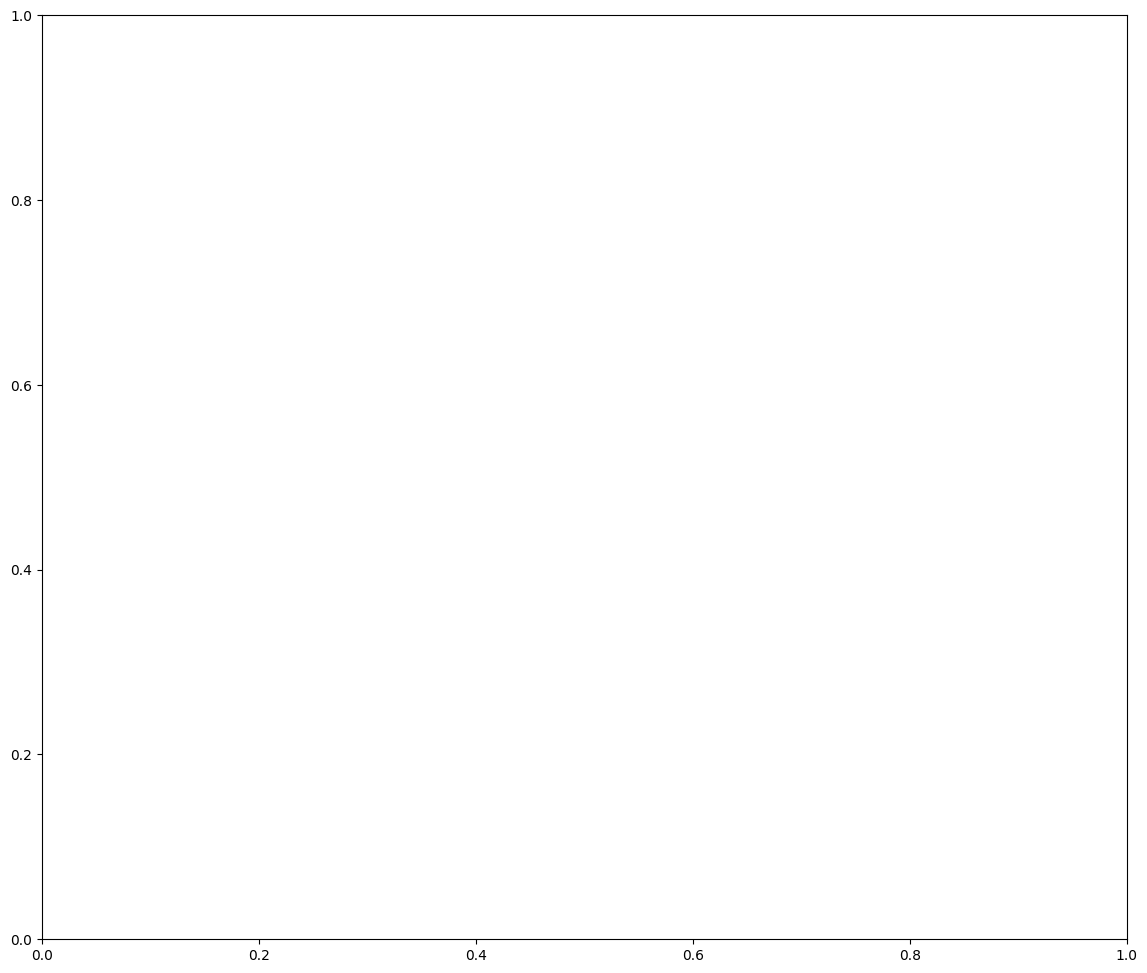

In [4]:
# # Example 2: L=50, up to N=2 particles
fig, ax = plt.subplots(figsize=(14,12))

L = 65
max_particles = 2
t_max = 40
num_samples = 200
omega_c = 0
times = np.linspace(0, t_max, num_samples)
basis, sector_dims = generate_full_basis_structured(L, max_N=max_particles)
# print(f"basis = ")
# print([bin(num)[2:] for num in basis])
# print(f"basis length = {len(basis)}")
kappa_vals = np.linspace(0,0.35,30)     # N=0 to N=2 sector coupling constant/exchange interaction/hopping term
# keep_sites = [L//2, L//2 - 1, L//2 + 1]
probe_sites_list = [[j-1, j, j+1] for j in range(1, L-1)]
D_all = [0]*len(kappa_vals)
F_all = [0]*len(kappa_vals)
S_all = [0]*len(kappa_vals)
psi_t_all = [0]*len(kappa_vals)

# print("\n" + "="*60)
# print("Basis structure:")
# print("="*60)
dim_N1 = 0
for N in range(max_particles+1):
    start, end, dim = sector_dims[N]
    if N == 1:
        dim_N1 = dim
    # print(f"N={N}: basis[{start}:{end}] has {dim} states")

# --- Function to compute observables at a single time ---

def compute_metrics(t):
    psi = evecs @ (np.exp(-1j * evals * t) * proj_psi0)
    rho_full_t = np.outer(psi, psi.conj())

    D_vals = []
    IF_vals = []
    S_vals = []

    for keep_sites in probe_sites_list:
        rhoA_t = partial_trace_rho_bitbasis(rho_full_t, basis, L, keep_sites, normalize_trace=True)
        rhoA_th = rhoA_thermal_dict[tuple(keep_sites)]  # precomputed thermal reduced state for this probe

        F = fidelity(rhoA_t, rhoA_th)
        Dm = trace_distance_calc(rhoA_t, rhoA_th)
        Sm = relative_entropy(rhoA_t, rhoA_th)

        D_vals.append(Dm)
        IF_vals.append(1.0 - F)
        S_vals.append(Sm)

    # average over probes
    return float(np.mean(D_vals)), float(np.mean(IF_vals)), float(np.mean(S_vals)), psi

E_norm_final = np.zeros(len(kappa_vals), dtype=float)   # normalized energy at final time
E_norm_initial = np.zeros(len(kappa_vals), dtype=float)   # normalized energy at final time
E_final      = np.zeros(len(kappa_vals), dtype=float)   # raw energy (optional)
E_initial      = np.zeros(len(kappa_vals), dtype=float)   # raw energy (optional)
ratios = []

for i, kappa in enumerate(kappa_vals):

    ratio = kappa / (1/np.sqrt(dim_N1))
    ratios.append(ratio)

    # --- Hamiltonian and initial state ---
    H = create_block_diagonal_GUE(L, basis, kappa, sector_dims = sector_dims, max_particles = max_particles)

    # --- Initial state: 2 particles on first two sites (sites 0 and 1) ---
    N = 2
    start_2, end_2, dim_2 = sector_dims[N]

    state_bit = (1 << L-1) | (1 << L-2)   # particles on sites 0 and 1 of excitons
    # equivalently: state_bit = 3

    idx_in_sector = basis[start_2:end_2].index(state_bit)
    idx_full = start_2 + idx_in_sector

    psi0 = np.zeros(len(basis), dtype=complex)
    # psi0[idx_full] = 1.0
    # psi0[start_2:end_2] = 1/np.sqrt(dim_2)            # Initializes equal superposition in the N = 2 sector

    # D = len(basis)
    # psi0 = np.ones(D, dtype=complex) / np.sqrt(D)       # Uniform superposition over the basis states

    psi0[0] = 1             # Initializes the cavity to have two excitations

    # --- Thermal state and reduced version ---
    evals, evecs = np.linalg.eigh(H)
    proj_psi0 = evecs.T.conj() @ psi0
    beta_star, _ = find_beta_with_neg_temps(H, psi0, bracket=(-100, 100))
    weights = np.exp(-beta_star * evals)
    weights /= np.sum(weights)
    rho_thermal_full = (evecs * weights[np.newaxis, :]) @ evecs.conj().T
    rhoA_thermal_dict = {}
    for ks in probe_sites_list: 
        rhoA_thermal_dict[tuple(ks)] = partial_trace_rho_bitbasis(rho_thermal_full, basis, L, ks, normalize_trace=True)

    t_final = times[-1]

    # State at final time using spectral decomposition (same as compute_metrics)
    psi_final = evecs @ (np.exp(-1j * evals * t_final) * proj_psi0)

    # Energy expectation value at final time
    # (use vdot for bra-ket; gives <psi|H|psi>)
    E_t = np.vdot(psi_final, H @ psi_final).real
    E_0 = np.vdot(psi0, H @ psi0).real

    # Normalize using spectral min/max (stable & cheap)
    E_min = float(evals[0])
    E_max = float(evals[-1])

    E_final[i] = E_t
    E_initial[i] = E_0
    E_norm_final[i] = (E_t - E_min) / (E_max - E_min)
    E_norm_initial[i] = (E_0 - E_min) / (E_max - E_min)
    evals_norm = (evals[1:-1] - E_min) / (E_max - E_min)
    mask = (evals_norm >= 0.460) & (evals_norm <= 0.530)
    label = 'Eigenvalues of H' if i == 0 else '_nolegend_'
    ax.scatter([ratio]*mask.sum(), evals_norm[mask], s=1, color='black', alpha=0.5, label=label)

    # --- Parallel execution ---
    results = Parallel(n_jobs=-1)(delayed(compute_metrics)(t) for t in times)

    # --- Unpack results ---
    D_all[i], F_all[i], S_all[i], psi_t_all[i] = map(np.array, zip(*results))

    Ns = sorted(sector_dims.keys())
    P = np.zeros((len(times), len(Ns)), float)

    for k, psi in enumerate(psi_t_all[i]):
        probs = sector_probabilities_from_psi(psi, sector_dims)
        for j, N in enumerate(Ns):
            P[k, j] = probs.get(N, 0.0)

    # print(f"Sector probabilities for $\kappa$ = {kappa} \n")
    # for k, t in enumerate(times):
        # line = [f"N={N}: {P[k, j]:.6f}" for j, N in enumerate(Ns)]
        # print(f"t = {t:8.3f} | " + ", ".join(line))
print(E_final)

ax.plot(ratios, E_norm_final, marker='o', label=r'$\langle H \rangle_t$', linewidth = 3)
# ax.plot(ratios, E_norm_initial, marker='*', label='initial time')
ax.set_xlabel(r"$g/\sigma$", fontsize=32)
ax.set_ylabel(r"$(E-E_{\min})/(E_{\max}-E_{\min})$", fontsize=32)
ax.tick_params(axis='both', which='major', labelsize=26)
ax.legend(fontsize=20)
plt.tight_layout()
plt.show()


# Observation, Feb 17th, 3:14pm: 
# (i) At low g, the spacings between in-between eigenstates are non-uniform. At high g, the spacings become very uniform
# (ii) Plot does not change with time. Makes sense because e^-iHt is energy conserving.
# (iii) For different g, meaning different H, my initial and final states are located at different points in the spectrum. Maybe this has something to do with the discreteness. 

# Observation, Feb 18th, 2:32pm:
# (i) I think g contributes to the magnitude of the oscillations of the TD and S(E=<H>) or DoS @ E=<H> determines the TD value
# (ii) The spectrum is much more dense, and more importantly, evenly densed at higher gs. Does this have anything to do
# with the TD? Meaning for evenly densed, I should see less TD and non-uniformly densed, I should see less TD? 
# I do think so because the ability to thermalize (or TD) depends on the WD statistics of the Hamiltonian I think right?

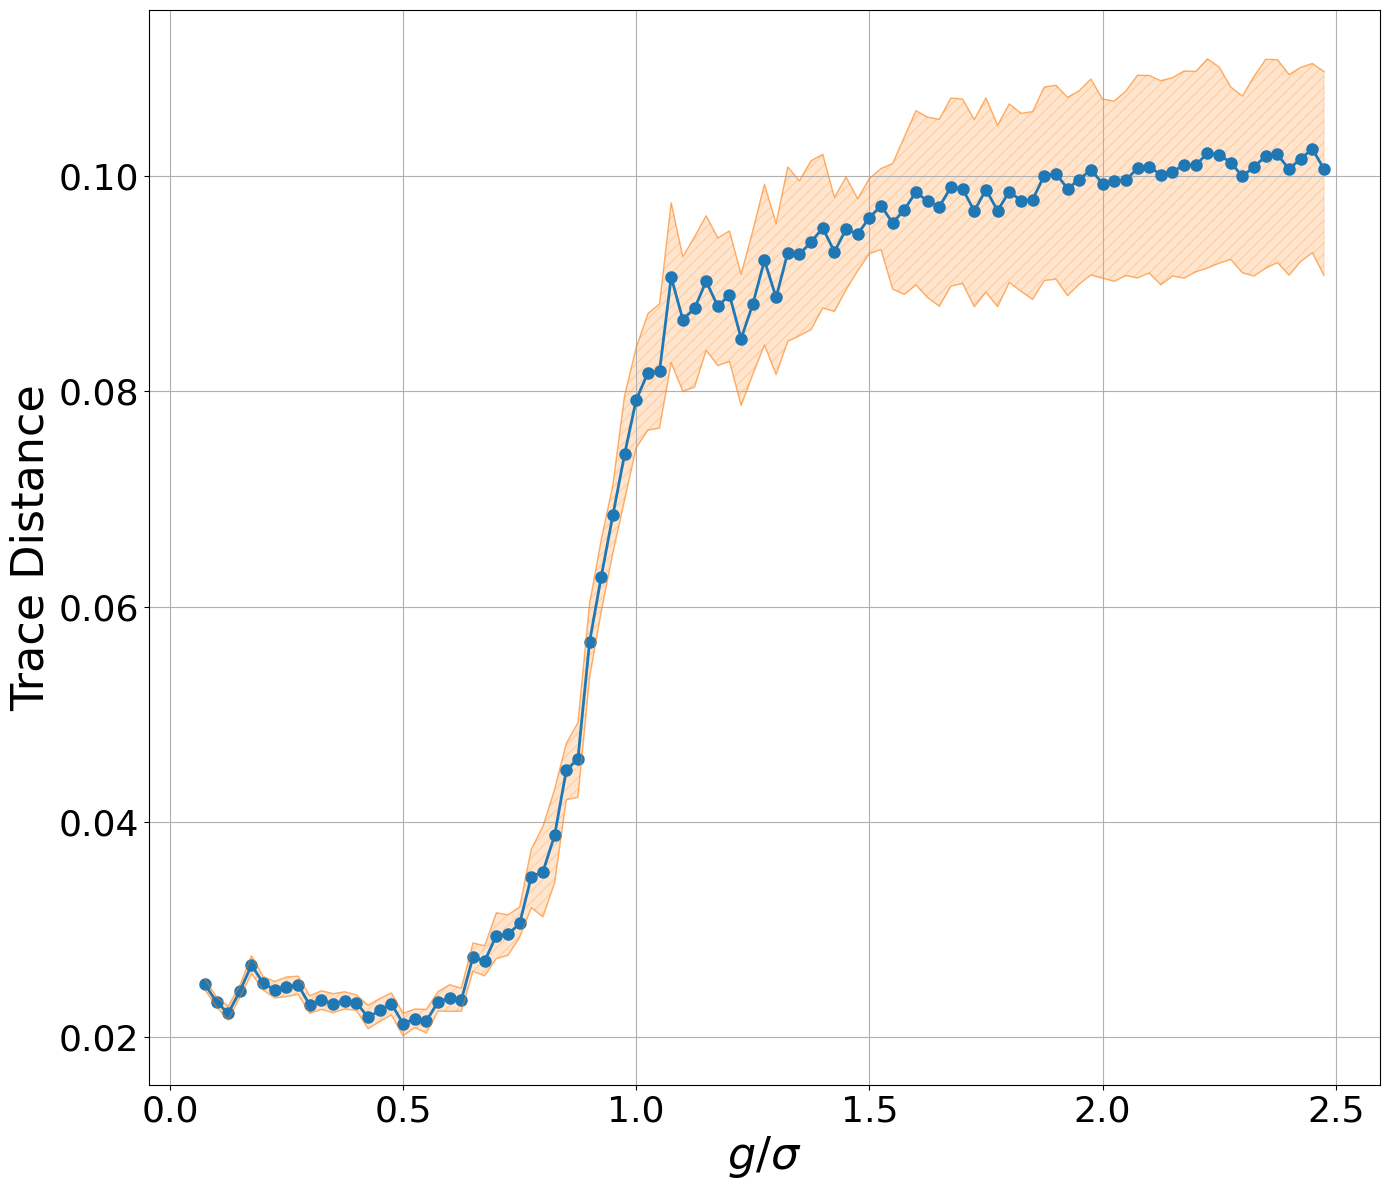

<Figure size 640x480 with 0 Axes>

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from numpy.lib.stride_tricks import sliding_window_view

# --- Moving Statistics ---
def moving_average(x, window=5):
    return np.convolve(x, np.ones(window)/window, mode='valid')

def moving_max(x, window=5):
    return sliding_window_view(x, window).max(axis=1)

def moving_min(x, window=5):
    return sliding_window_view(x, window).min(axis=1)

t = np.asarray(times, float)
window = 10
results = []
n=3
for i, kappa in enumerate(kappa_vals[n:]):
    i+=n
    ratio = kappa / (1/np.sqrt(dim_N1))
    y = np.asarray(D_all[i], float)
    half = len(y) // 2
    y_latter = y[half:]

    windows = sliding_window_view(y_latter, window)
    y_ma  = windows.mean(axis=1)
    y_max = windows.max(axis=1)
    y_min = windows.min(axis=1)

    results.append({
        'g/sigma': ratio,
        'td':      y_ma.mean(),
        'td_max':  y_max.mean(),
        'td_min':  y_min.mean(),
    })

df = pd.DataFrame(results).sort_values('g/sigma')

# --- Plot ---
plt.figure(figsize=(14, 12))

plt.plot(df['g/sigma'], df['td'], 'o-', linewidth=2, markersize=8)
line, = plt.plot(df['g/sigma'], df['td_max'], '-', linewidth=1, alpha=0.5)
color = line.get_color()
plt.plot(df['g/sigma'], df['td_min'], '-', color=color, linewidth=1, alpha=0.5)
plt.fill_between(df['g/sigma'], df['td_min'], df['td_max'], color=color, alpha=0.2, hatch='///')

plt.xlabel(r'$g/\sigma$', fontsize=32)
plt.ylabel('Trace Distance', fontsize=32)
plt.tick_params(axis='both', which='major', labelsize=26)
plt.grid(True)
plt.tight_layout()
plt.show()

# plt.xlabel(r'Time', fontsize=32)
# plt.ylabel('Trace distance', fontsize=32)
# plt.legend(fontsize=20)
# plt.tick_params(axis='both', which='major', labelsize=26)
# plt.grid(True)
# plt.tight_layout()
# plt.show()


# Conclusion 20/01, 10:30pm: I see that the system does not thermalize as I increase the cavity exciton coupling strength, as I predicted.
# But I'm curious as to why it loses thermalization at such low ratios. I expected it to do at much higher ratios ~ 0.5-1.
# Next, I should look at two things: 1) Make the message pictorially better for the paper; 2) Add other couplings and dephasing
# 3) Tune the exciton coupling strength as well.

# Update, Feb 7th, 6:42pm: I added coupling to the N=1 sector too and I still see the jumps. So I am fine.
# Update, Feb 7th, 7:02pm: I initialized the system to have two excitations in the cavity. The initial distance measure
# is much better, begins to thermalize at low kappa, thermalizes more at a higher kappa (makes sense coz lower kappa was
# possibly lesser than thermalization time) and then ceases to thermalize similar to before. I still see jumps.


Multiple Ls

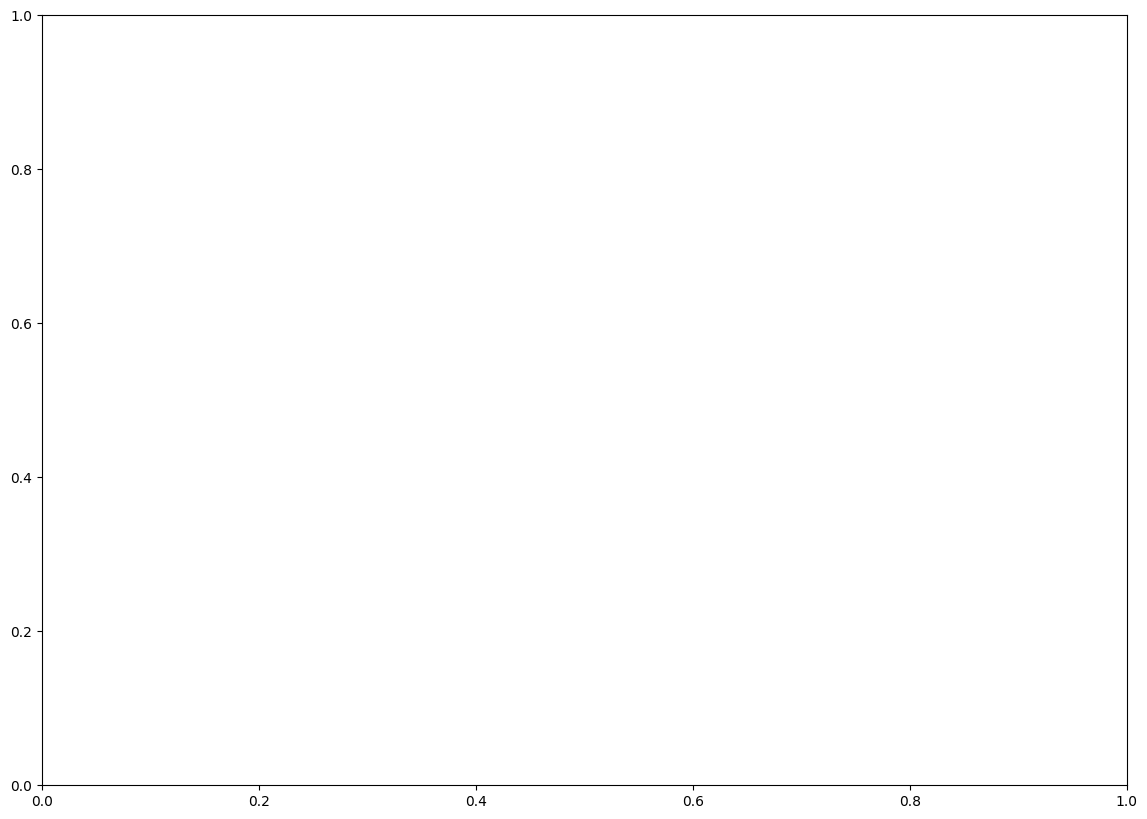

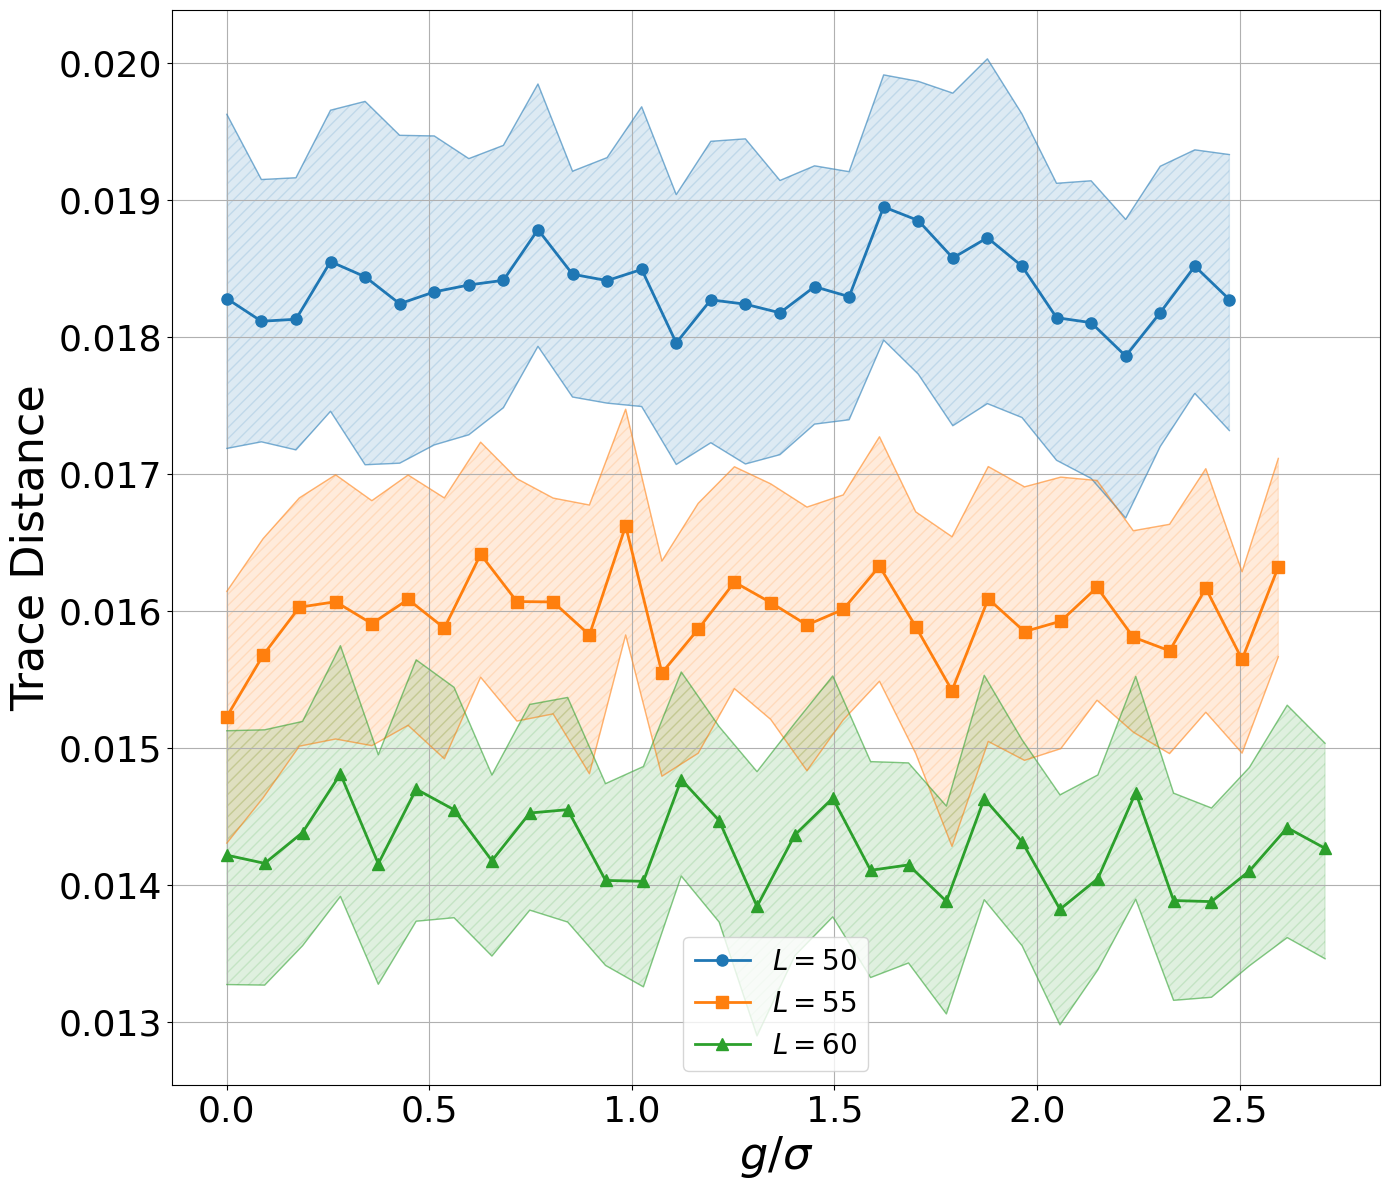

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from numpy.lib.stride_tricks import sliding_window_view
from joblib import Parallel, delayed

# ── colours/styles per L ──────────────────────────────────────────────────────
L_vals   = [50, 55, 60]
colors   = ['tab:blue', 'tab:orange', 'tab:green']
markers  = ['o', 's', '^']

fig1, ax1 = plt.subplots(figsize=(14, 10))   # energy plot  (was: ax)
fig2, ax2 = plt.subplots(figsize=(14, 12))   # trace-distance plot

# Storage keyed by L
all_data = {}   # all_data[L] = dict with ratios, E_norm_final, D_all, kappa_vals, dim_N1

for L, color, marker in zip(L_vals, colors, markers):

    # ── parameters ───────────────────────────────────────────────────────────
    max_particles = 2
    t_max         = 40
    num_samples   = 200
    omega_c       = 0
    times         = np.linspace(0, t_max, num_samples)

    basis, sector_dims = generate_full_basis_structured(L, max_N=max_particles)
    kappa_vals = np.linspace(0, 0.35, 30)
    probe_sites_list = [[j-1, j, j+1] for j in range(1, L-1)]

    D_all       = [0] * len(kappa_vals)
    F_all       = [0] * len(kappa_vals)
    S_all       = [0] * len(kappa_vals)
    psi_t_all   = [0] * len(kappa_vals)

    dim_N1 = 0
    for N in range(max_particles + 1):
        start, end, dim = sector_dims[N]
        if N == 1:
            dim_N1 = dim

    # ── per-time metric function (closure over basis, probe_sites_list, etc.) ─
    def compute_metrics(t, evecs=None, evals=None, proj_psi0=None,
                        rhoA_thermal_dict=None):
        psi = evecs @ (np.exp(-1j * evals * t) * proj_psi0)
        rho_full_t = np.outer(psi, psi.conj())

        D_vals, IF_vals, S_vals = [], [], []
        for keep_sites in probe_sites_list:
            rhoA_t  = partial_trace_rho_bitbasis(rho_full_t, basis, L,
                                                  keep_sites, normalize_trace=True)
            rhoA_th = rhoA_thermal_dict[tuple(keep_sites)]

            D_vals.append(trace_distance_calc(rhoA_t, rhoA_th))
            IF_vals.append(1.0 - fidelity(rhoA_t, rhoA_th))
            S_vals.append(relative_entropy(rhoA_t, rhoA_th))

        return (float(np.mean(D_vals)),
                float(np.mean(IF_vals)),
                float(np.mean(S_vals)),
                psi)

    E_norm_final  = np.zeros(len(kappa_vals))
    E_norm_initial= np.zeros(len(kappa_vals))
    ratios        = []

    for i, kappa in enumerate(kappa_vals):
        ratio = kappa / (1 / np.sqrt(dim_N1))
        ratios.append(ratio)

        H = create_block_diagonal_GUE(L, basis, kappa,
                                      sector_dims=sector_dims,
                                      max_particles=max_particles)

        N_part = 2
        start_2, end_2, dim_2 = sector_dims[N_part]
        state_bit   = (1 << L-1) | (1 << L-2)
        idx_in_sector = basis[start_2:end_2].index(state_bit)
        idx_full    = start_2 + idx_in_sector

        psi0 = np.zeros(len(basis), dtype=complex)
        # psi0[0] = 1   # vacuum / zero-excitation initial state

        psi0[idx_full] = 1.0            # Initializes localized excitations of excitons
        # psi0[start_2:end_2] = 1/np.sqrt(dim_2)            # Initializes equal superposition in the N = 2 sector

        evals, evecs = np.linalg.eigh(H)
        proj_psi0    = evecs.T.conj() @ psi0

        beta_star, _ = find_beta_with_neg_temps(H, psi0, bracket=(-100, 100))
        weights      = np.exp(-beta_star * evals)
        weights     /= np.sum(weights)
        rho_thermal_full = (evecs * weights[np.newaxis, :]) @ evecs.conj().T

        rhoA_thermal_dict = {
            tuple(ks): partial_trace_rho_bitbasis(
                rho_thermal_full, basis, L, ks, normalize_trace=True)
            for ks in probe_sites_list
        }

        # # energy bookkeeping
        # t_final   = times[-1]
        # psi_final = evecs @ (np.exp(-1j * evals * t_final) * proj_psi0)
        # E_t  = np.vdot(psi_final, H @ psi_final).real
        # E_0  = np.vdot(psi0,      H @ psi0     ).real
        # E_min, E_max = float(evals[0]), float(evals[-1])

        # E_norm_final[i]  = (E_t - E_min) / (E_max - E_min)
        # E_norm_initial[i]= (E_0 - E_min) / (E_max - E_min)

        # # eigenvalue scatter (middle band) — Figure 1
        # evals_norm = (evals[1:-1] - E_min) / (E_max - E_min)
        # mask  = (evals_norm >= 0.460) & (evals_norm <= 0.530)
        # label_ev = f'Eigenvalues L={L}' if i == 0 else '_nolegend_'
        # ax1.scatter([ratio] * mask.sum(), evals_norm[mask],
        #             s=1, color=color, alpha=0.3, label=label_ev)

        # parallel time evolution
        results_t = Parallel(n_jobs=-1)(
            delayed(compute_metrics)(t,
                                     evecs=evecs,
                                     evals=evals,
                                     proj_psi0=proj_psi0,
                                     rhoA_thermal_dict=rhoA_thermal_dict)
            for t in times
        )
        D_all[i], F_all[i], S_all[i], psi_t_all[i] = map(np.array, zip(*results_t))

    # store for trace-distance plot
    all_data[L] = dict(ratios=ratios, E_norm_final=E_norm_final,
                       D_all=D_all, kappa_vals=kappa_vals, dim_N1=dim_N1)

    # # ── Figure 1: energy vs g/sigma ──────────────────────────────────────────
    # ax1.plot(ratios, E_norm_final,
    #          marker=marker, color=color, linewidth=3,
    #          label=rf'$\langle H \rangle_{{t}},\ L={L}$')

    # ── Figure 2: trace distance vs g/sigma ──────────────────────────────────
    window = 10
    n_skip = 3
    td_results = []

    for i, kappa in enumerate(kappa_vals):
        ratio = kappa / (1 / np.sqrt(dim_N1))
        y     = np.asarray(D_all[i], float)
        half  = len(y) // 2
        wins  = sliding_window_view(y[half:], window)
        td_results.append({
            'g/sigma': ratio,
            'td':      wins.mean(axis=1).mean(),
            'td_max':  wins.max(axis=1).mean(),
            'td_min':  wins.min(axis=1).mean(),
        })

    df = pd.DataFrame(td_results).sort_values('g/sigma')

    ax2.plot(df['g/sigma'], df['td'],
             f'{marker}-', color=color, linewidth=2, markersize=8,
             label=rf'$L={L}$')
    ax2.plot(df['g/sigma'], df['td_max'], '-', color=color, linewidth=1, alpha=0.5)
    ax2.plot(df['g/sigma'], df['td_min'], '-', color=color, linewidth=1, alpha=0.5)
    ax2.fill_between(df['g/sigma'], df['td_min'], df['td_max'],
                     color=color, alpha=0.15, hatch='///')

# # ── Figure 1 formatting ───────────────────────────────────────────────────────
# ax1.set_xlabel(r'$g/\sigma$', fontsize=32)
# ax1.set_ylabel(r'$(E-E_{\min})/(E_{\max}-E_{\min})$', fontsize=32)
# ax1.tick_params(axis='both', which='major', labelsize=26)
# ax1.legend(fontsize=18)
# fig1.tight_layout()
# fig1.savefig('energy_vs_g_sigma.pdf', dpi=150)

# ── Figure 2 formatting ───────────────────────────────────────────────────────
ax2.set_xlabel(r'$g/\sigma$', fontsize=32)
ax2.set_ylabel('Trace Distance', fontsize=32)
ax2.tick_params(axis='both', which='major', labelsize=26)
ax2.legend(fontsize=20)
ax2.grid(True)
fig2.tight_layout()
fig2.savefig('trace_distance_vs_g_sigma.pdf', dpi=150)

plt.show()

Level Spacing Statistics

<>:129: SyntaxWarning: invalid escape sequence '\s'
<>:129: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_1848243/3359713753.py:129: SyntaxWarning: invalid escape sequence '\s'
  plt.ylabel('$(g/\sigma)/s$', fontsize=32)


min_gaps = [0.008980370880707262, 0.043311169981932296, 0.052203420643246824, 0.04650610844634046, 0.0725101703653813, 0.03748072059915691, 0.04530033556749787, 0.026794971931031933, 0.023065813848813396, 0.017688690233211048]
most_common_gaps = [0.0, 0.0631308790089869, 0.1727487331367652, 0.1693980838161346, 0.3026951279655713, 0.0798161148854646, 0.04873752262457637, 0.049456556973723885, 0.04827888013977267, 0.050474652808289264]


<Figure size 1400x1200 with 0 Axes>

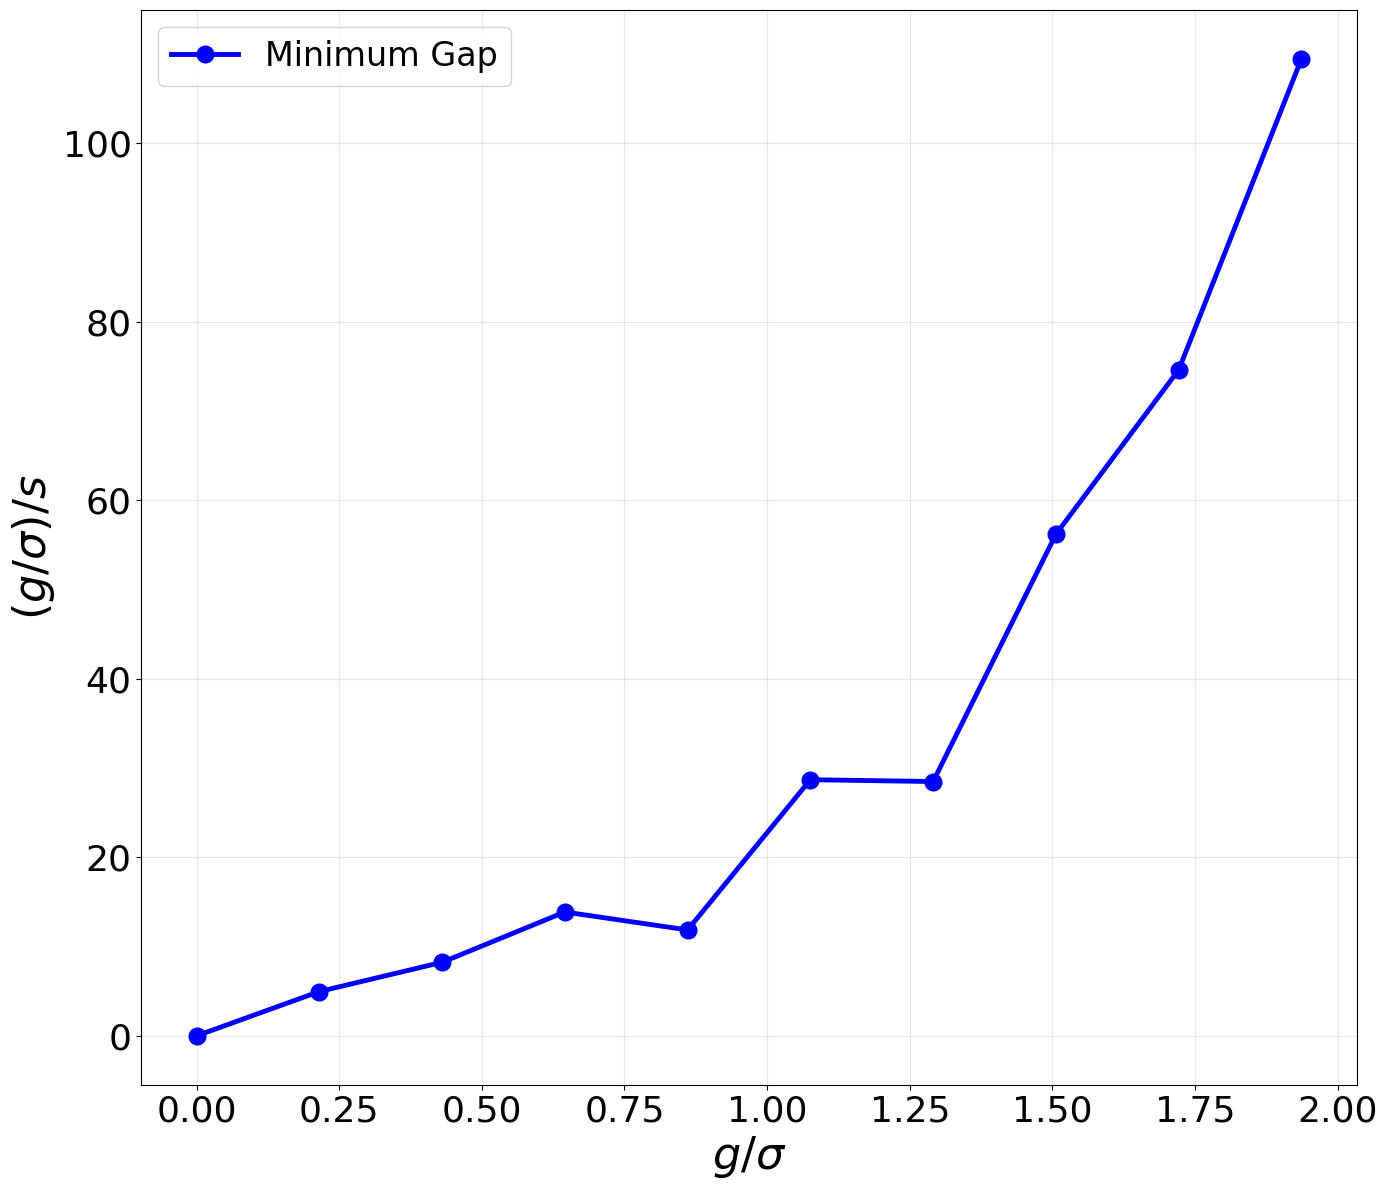

In [ ]:
from scipy.stats import expon, chi

def get_level_spacings(eigenvalues):
    """
    Compute nearest-neighbor level spacings from eigenvalues.
    
    Parameters
    ----------
    eigenvalues : array
        Sorted eigenvalues
    
    Returns
    -------
    spacings : array
        Nearest-neighbor level spacings
    """
    # Sort eigenvalues
    E_sorted = np.sort(eigenvalues)
    
    # Compute spacings
    spacings = np.diff(E_sorted)
    
    return spacings

def normalize_spacings(spacings):
    """
    Normalize spacings to have mean = 1 (unfolding).
    
    Parameters
    ----------
    spacings : array
        Raw level spacings
    
    Returns
    -------
    s : array
        Normalized spacings with mean = 1
    """
    mean_spacing = np.mean(spacings)
    s = spacings / mean_spacing
    return s

def poisson_distribution(s):
    """Poisson distribution: P(s) = exp(-s)"""
    return np.exp(-s)

def wigner_dyson_distribution(s, beta=2):
    """
    Wigner-Dyson distribution for GUE (beta=2).
    P(s) = (32/π²) s² exp(-4s²/π)
    """
    if beta == 2:  # GUE
        return (32 / np.pi**2) * s**2 * np.exp(-4 * s**2 / np.pi)
    elif beta == 1:  # GOE
        return (np.pi / 2) * s * np.exp(-np.pi * s**2 / 4)
    else:
        raise ValueError("Only beta=1 (GOE) or beta=2 (GUE) supported")

kappa_vals = np.linspace(0,0.25,10)     # N=0 to N=2 sector coupling constant/exchange interaction/hopping term

for kappa in kappa_vals:
    H = create_block_diagonal_GUE(L, basis, kappa, sector_dims = sector_dims, max_particles = max_particles)

# Manually select kappas
selected_indices = [0, 3, 6, 9]  
selected_kappas = [kappa_vals[i] for i in selected_indices]

plt.figure(figsize=(14, 12))

# Use distinct colors
colors = ['blue', 'pink', 'orange', 'green']

# Decreasing opacity for higher kappas
alphas = [0.9, 0.6, 0.4, 0.2]  # From 0.9 to 0.3

min_gaps = [0]*10
min_gap=0
most_common_gaps = [0]*10
most_common_gap=0
ratios = [0]*10
fluc_values_min = [0]*10
fluc_values_most_common = [0]*10

for idx, kappa in enumerate(kappa_vals):
    # print(f"\nProcessing kappa = {kappa:.2f}")
    
    H = create_block_diagonal_GUE(L, basis, kappa, sector_dims=sector_dims, max_particles=max_particles)
    eigenvalues_full = np.linalg.eigvalsh(H)
    spacings_full = normalize_spacings(get_level_spacings(eigenvalues_full))
    min_gap = np.min(spacings_full)
    
    ratio = kappa/(1/np.sqrt(dim_N1))
    ratios[idx] = ratio
    min_gaps[idx] = min_gap
    fluc_values_min[idx] = ratio/min_gap
    
    # plt.hist(spacings_full, bins=50, density=True, alpha=alphas[idx], 
    #          label=f'g = {kappa:.2f}', edgecolor='black', 
    #          color=colors[idx], linewidth=1.5)
    
    
    hist, bin_edges = np.histogram(spacings_full, bins=50)
    max_bin_idx = np.argmax(hist)
    most_common_gap = (bin_edges[max_bin_idx] + bin_edges[max_bin_idx + 1])/2
    
    most_common_gaps[idx] = kappa/most_common_gap
    fluc_values_most_common[idx] = ratio/most_common_gap

# # Theoretical curve
# s_theory = np.linspace(0, 4, 1000)
# wigner_dyson = wigner_dyson_distribution(s_theory, beta=2)
# plt.plot(s_theory, wigner_dyson, 'r--', linewidth=4, label='Wigner-Dyson')

# plt.xlabel('Normalized spacing, s', fontsize=32)
# plt.ylabel('P(s)', fontsize=32)
# plt.legend(fontsize=26, loc='upper right')
# plt.tick_params(axis='both', which='major', labelsize=26)
# plt.grid(True, alpha=0.3)
# plt.xlim(0, 4)
# plt.tight_layout()
# plt.show()
print(f"min_gaps = {min_gaps}")
print(f"most_common_gaps = {most_common_gaps}")
# Plot 3: Both on same plot
plt.figure(figsize=(14, 12))
plt.plot(ratios, fluc_values_min, 'o-', linewidth=3.5, markersize=12, color='blue', label='Minimum Gap')
# plt.plot(ratios, fluc_values_most_common, 's-', linewidth=3.5, markersize=12, color='green', label='Most Common Gap')
plt.xlabel(r'$g/\sigma$', fontsize=32)
plt.ylabel('$(g/\sigma)/s$', fontsize=32)
plt.legend(fontsize=24)
plt.tick_params(axis='both', which='major', labelsize=26)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# # Extract the N=2 sector
# N = 2
# start_idx, end_idx, dim_N = sector_dims[N]

# H = create_block_diagonal_GUE(L, basis, 0, sector_dims = sector_dims, max_particles = max_particles)

# print(f"Analyzing N={N} sector: dimension = {dim_N}")

# # Extract the block for N=2 sector
# H_block = H[start_idx:end_idx, start_idx:end_idx]

# # Diagonalize to get eigenvalues
# eigenvalues = np.linalg.eigvalsh(H_block)

# print(f"Number of eigenvalues: {len(eigenvalues)}")
# print(f"Energy range: [{eigenvalues[0]:.3f}, {eigenvalues[-1]:.3f}]")

# # Compute level spacings
# spacings = get_level_spacings(eigenvalues)

# # Normalize spacingsß
# s = normalize_spacings(spacings)

# print(f"Number of spacings: {len(s)}")
# print(f"Mean spacing (should be ~1): {np.mean(s):.3f}")

# # Plot histogram of normalized spacings
# plt.figure(figsize=(12, 8))

# # Histogram of data
# counts, bins, _ = plt.hist(s, bins=50, density=True, alpha=0.7, 
#                            label='Level spacings (N=2)', edgecolor='black')

# # Theoretical curves
# s_theory = np.linspace(0, np.max(s), 1000)
# poisson = poisson_distribution(s_theory)
# wigner_dyson = wigner_dyson_distribution(s_theory, beta=2)

# plt.plot(s_theory, poisson, 'r--', linewidth=3, label='Poisson')
# plt.plot(s_theory, wigner_dyson, 'b-', linewidth=3, label='Wigner-Dyson (GUE)')

# plt.xlabel('Normalized spacings', fontsize=24)
# plt.ylabel('P(s)', fontsize=24)
# plt.title(f'Level Spacing Distribution (N={N} sector, dim={dim_N})', fontsize=20)
# plt.legend(fontsize=18)
# plt.tick_params(axis='both', which='major', labelsize=20)
# plt.grid(True, alpha=0.3)
# plt.xlim(0, 4)
# plt.tight_layout()
# plt.show()

Level Spacing Ratio

kappa_vals = [0.         0.02777778 0.05555556 0.08333333 0.11111111 0.13888889
 0.16666667 0.19444444 0.22222222 0.25      ]
<r>(kappa) = [0.57258764 0.58644476 0.60544427 0.57966866 0.59715875 0.590021
 0.58140025 0.60263815 0.59779844 0.57737309]


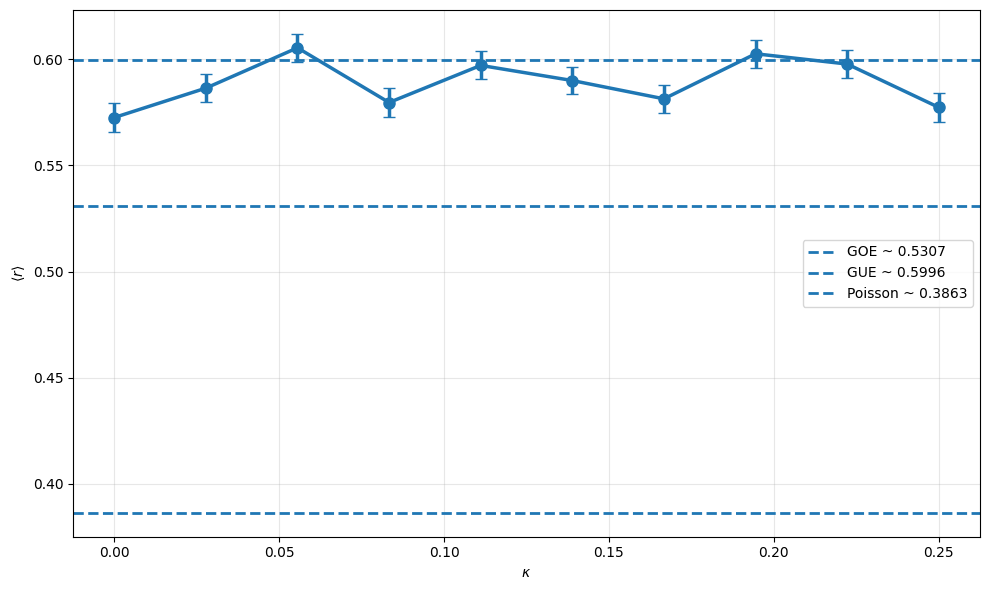

In [8]:
import numpy as np

def spacing_ratios(eigenvalues, eps=1e-14, unfold=False):
    """
    Compute r_i = min(s_i, s_{i+1}) / max(s_i, s_{i+1}) from sorted eigenvalues.

    Parameters
    ----------
    eigenvalues : array-like
        Eigenvalues (can be unsorted).
    eps : float
        Small threshold to avoid division by zero if spacings are ~0.
    unfold : bool
        If True, normalize spacings by their mean first. (Not required for r-statistics.)

    Returns
    -------
    r : ndarray
        Array of ratios r_i in [0,1].
    """
    E = np.sort(np.asarray(eigenvalues))
    s = np.diff(E)

    if unfold:
        m = np.mean(s)
        if m > 0:
            s = s / m

    # Filter out tiny/zero spacings (degeneracies / numerical ties)
    s = s[s > eps]
    if len(s) < 2:
        return np.array([])

    r = np.minimum(s[:-1], s[1:]) / np.maximum(s[:-1], s[1:])
    return r

def mean_spacing_ratio(eigenvalues, **kwargs):
    r = spacing_ratios(eigenvalues, **kwargs)
    return float(np.mean(r)) if r.size else np.nan

kappa_vals = np.linspace(0, 0.25, 10)

r_means = np.zeros(len(kappa_vals))
r_stds  = np.zeros(len(kappa_vals))  # optional error bar

for idx, kappa in enumerate(kappa_vals):
    H = create_block_diagonal_GUE(L, basis, kappa, sector_dims=sector_dims, max_particles=max_particles)
    eigenvalues_full = np.linalg.eigvalsh(H)

    r = spacing_ratios(eigenvalues_full, eps=1e-14, unfold=False)
    r_means[idx] = np.mean(r)
    r_stds[idx]  = np.std(r) / np.sqrt(len(r))  # standard error of mean (optional)

print("kappa_vals =", kappa_vals)
print("<r>(kappa) =", r_means)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.errorbar(kappa_vals, r_means, yerr=r_stds, fmt='o-', linewidth=2.5, markersize=8, capsize=4)
plt.axhline(0.5307, linestyle='--', linewidth=2, label='GOE ~ 0.5307')
plt.axhline(0.5996, linestyle='--', linewidth=2, label='GUE ~ 0.5996')
plt.axhline(0.3863, linestyle='--', linewidth=2, label='Poisson ~ 0.3863')
plt.xlabel(r'$\kappa$')
plt.ylabel(r'$\langle r \rangle$')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------
# Helpers
# ---------------------------
def von_neumann_entropy(rhoA, base=2, eps=1e-12):
    """S(rho) = -Tr rho log rho, using eigenvalues of rho."""
    rhoA = 0.5 * (rhoA + rhoA.conj().T)               # hermitize
    w = np.linalg.eigvalsh(rhoA).real
    w = np.clip(w, 0.0, 1.0)
    w = w[w > eps]
    if w.size == 0:
        return 0.0
    log = np.log2 if base == 2 else np.log
    return float(-np.sum(w * log(w)))

def entanglement_entropy_vs_energy(H, basis, L, keep_sites,
                                  which="middle", n_states=300):
    """
    Compute eigenstate entanglement entropy S_A(E) for selected eigenstates.
    Returns arrays (E_sel, S_sel).
    """
    evals, evecs = np.linalg.eigh(H)
    D = len(evals)

    if n_states is None or n_states >= D:
        sel = np.arange(D)
    else:
        if which == "middle":
            mid = D // 2
            half = n_states // 2
            lo = max(0, mid - half)
            hi = min(D, lo + n_states)
            sel = np.arange(lo, hi)
        elif which == "lowest":
            sel = np.arange(0, n_states)
        elif which == "highest":
            sel = np.arange(D - n_states, D)
        else:
            raise ValueError("which must be 'middle', 'lowest', or 'highest'.")

    E_sel = evals[sel]
    S_sel = np.zeros_like(E_sel, dtype=float)

    for ii, mu in enumerate(sel):
        psi = evecs[:, mu]
        rho_full = np.outer(psi, psi.conj())
        rhoA = partial_trace_rho_bitbasis(
            rho_full, basis, L, keep_sites, normalize_trace=True
        )
        S_sel[ii] = von_neumann_entropy(rhoA, base=2)

    return E_sel, S_sel


# ---------------------------
# Main parameters (yours)
# ---------------------------
L = 50
max_particles = 2
basis, sector_dims = generate_full_basis_structured(L, max_N=max_particles)

kappa_vals = np.linspace(0, 0.25, 10)  # treat as cavity-exciton coupling in YOUR code

# Choose a single subsystem A for eigenstate entanglement:
keep_sites = [L//2 - 1, L//2, L//2 + 1]   # 3-site block in the middle

# How many eigenstates to sample (middle of spectrum is where ETH is usually clearest)
n_states = 250
which = "middle"

# ---------------------------
# Compute and plot
# ---------------------------
plt.figure(figsize=(8, 5))

for kappa in kappa_vals:
    # Build Hamiltonian at this kappa
    H = create_block_diagonal_GUE(
        L, basis, kappa,
        sector_dims=sector_dims,
        max_particles=max_particles
    )

    # Eigenstate entanglement entropy vs energy
    E, S = entanglement_entropy_vs_energy(
        H, basis, L, keep_sites,
        which=which, n_states=n_states
    )

    # Scatter plot (each kappa one cloud)
    plt.scatter(E, S, s=10, alpha=0.65, label=f"$\\kappa$={kappa:.3f}")

plt.xlabel("Energy $E$")
plt.ylabel(r"Eigenstate entanglement entropy $S_A$ (bits)")
plt.title(f"$S_A(E)$ for subsystem A={keep_sites} (L={L}, N≤{max_particles})")
plt.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()
